##**TASK 2**

###Import statements

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

###Data load and cleaning

In [ ]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")
df = df.dropna(subset=["Rating"])
for col in ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]:
    df[col] = df[col].fillna("Unknown")

###Histogram of movie ratings

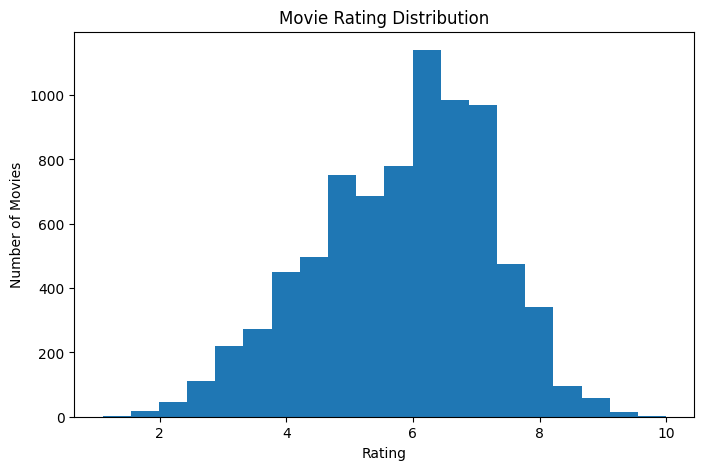

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["Rating"], bins=20)
plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.show()

###Data label encoding

In [ ]:
df = df[
    [
        "Genre",
        "Director",
        "Actor 1",
        "Actor 2",
        "Actor 3",
        "Rating"
    ]
]
encoders = {}
for col in ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

###Model training and prediction

In [ ]:
X = df.drop("Rating", axis=1)
y = df["Rating"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestRegressor(
    n_estimators=20,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

###Accuracy analysis

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"\nMAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")


MAE  : 1.04
RMSE : 1.30
R²   : 0.09


###User Predictions

In [ ]:
print("\nEnter Movie Details")
genre = input("Genre: ")
director = input("Director: ")
actor1 = input("Actor 1: ")
actor2 = input("Actor 2: ")
actor3 = input("Actor 3: ")
def encode_input(value, encoder):
    if value in encoder.classes_:
        return encoder.transform([value])[0]
    return 0
movie = pd.DataFrame({
    "Genre": [encode_input(genre, encoders["Genre"])],
    "Director": [encode_input(director, encoders["Director"])],
    "Actor 1": [encode_input(actor1, encoders["Actor 1"])],
    "Actor 2": [encode_input(actor2, encoders["Actor 2"])],
    "Actor 3": [encode_input(actor3, encoders["Actor 3"])]
})
predicted_rating = model.predict(movie)
print(f"\nPredicted Rating: {predicted_rating[0]:.2f}/10")


Enter Movie Details
Genre: Drama
Director: Rajkumar Hirani
Actor 1: Aamir Khan
Actor 2: Kareena Kapoor
Actor 3: Sharman Joshi

Predicted Rating: 6.98/10


###Scatter Plot

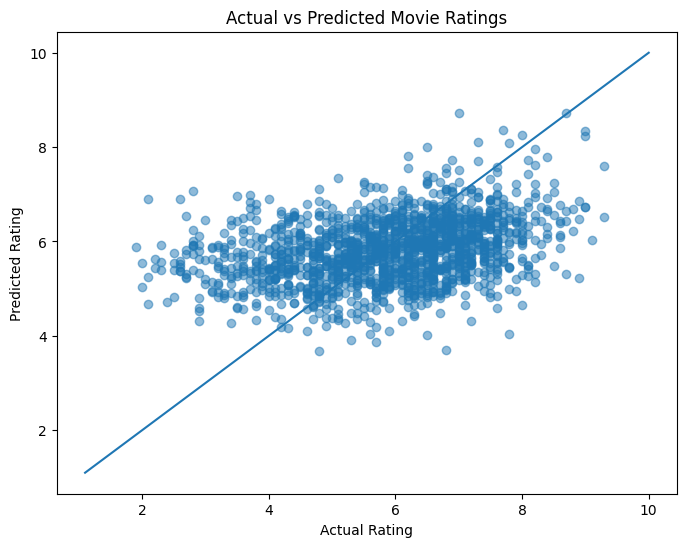

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")
plt.show()